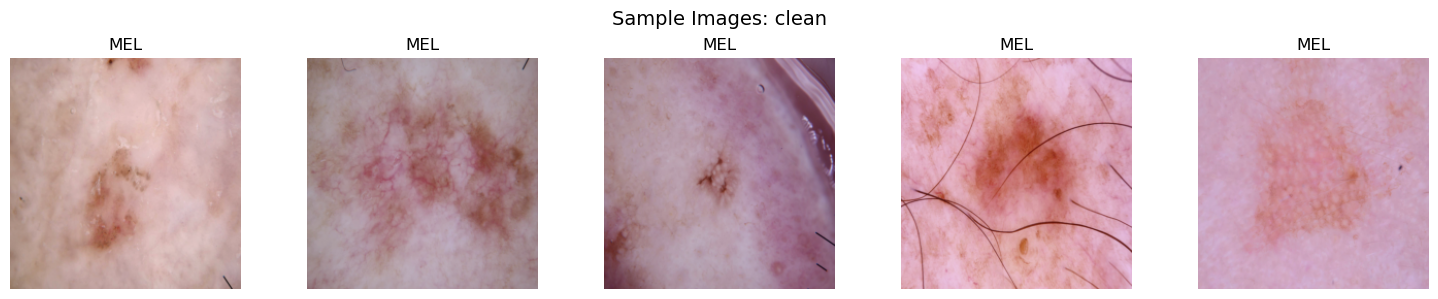

Evaluating clean: 100%|████████████████████████████████████████████████████████████████| 48/48 [03:46<00:00,  4.71s/it]


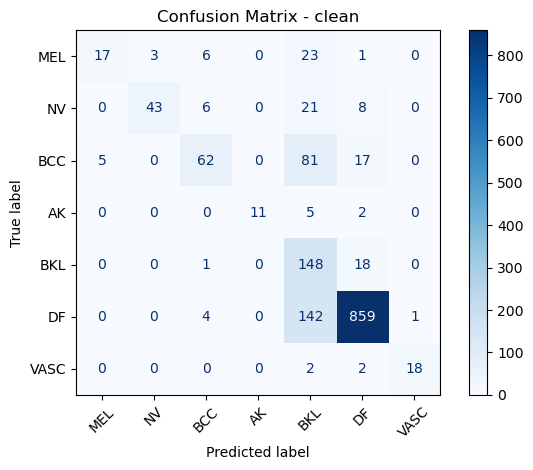

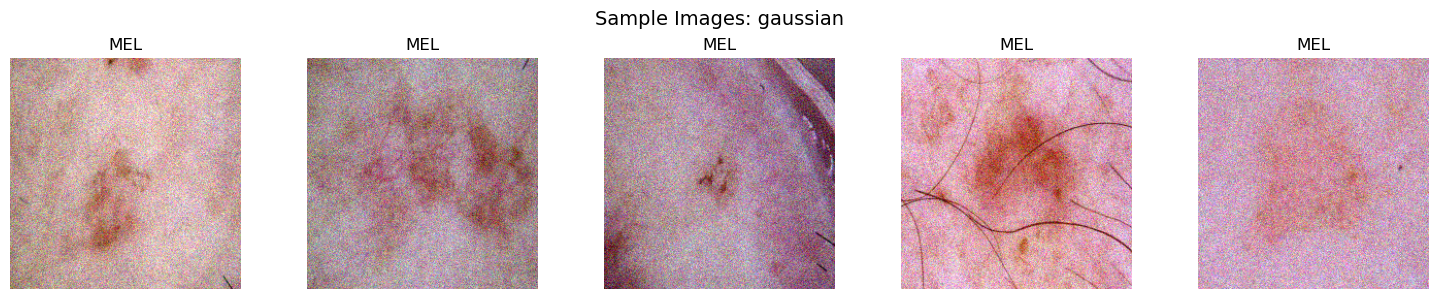

Evaluating gaussian: 100%|█████████████████████████████████████████████████████████████| 48/48 [03:33<00:00,  4.44s/it]


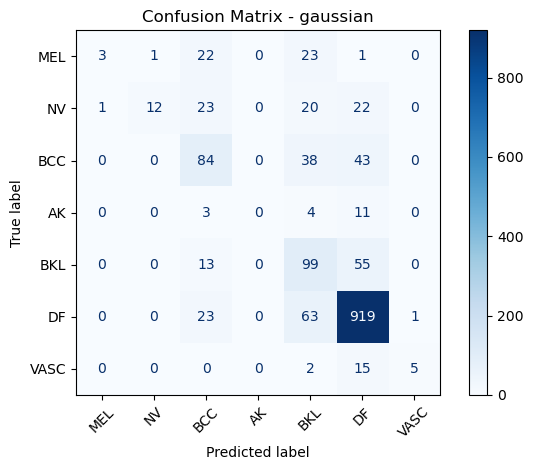

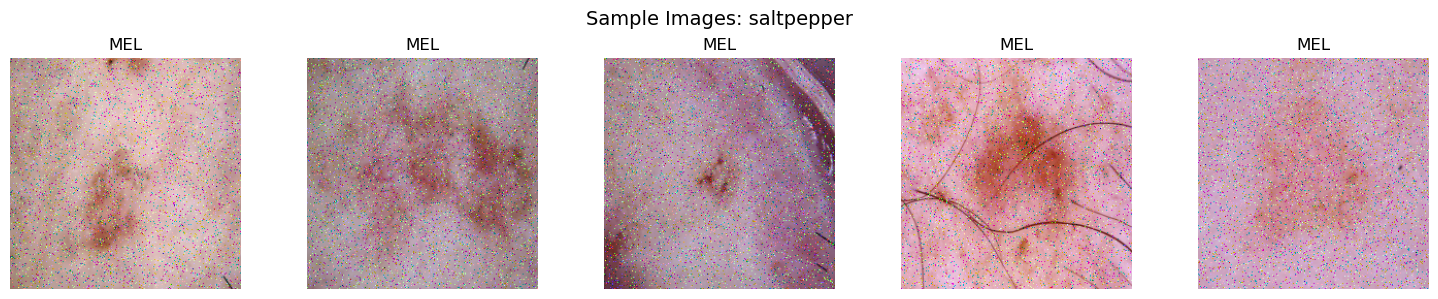

Evaluating saltpepper: 100%|███████████████████████████████████████████████████████████| 48/48 [03:38<00:00,  4.56s/it]


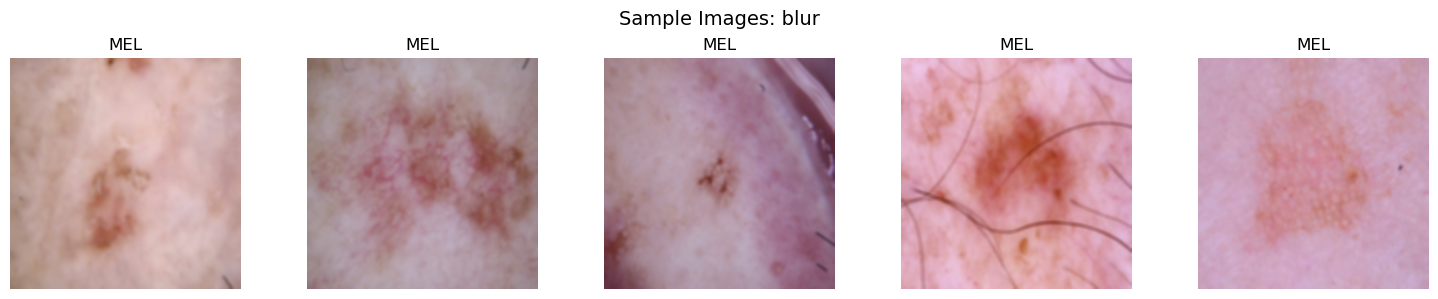

Evaluating blur: 100%|█████████████████████████████████████████████████████████████████| 48/48 [03:35<00:00,  4.49s/it]


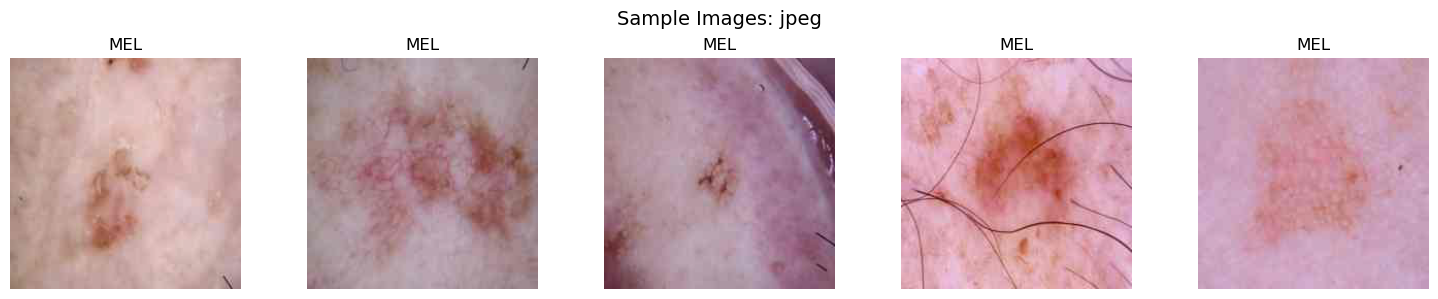

Evaluating jpeg: 100%|█████████████████████████████████████████████████████████████████| 48/48 [03:45<00:00,  4.69s/it]


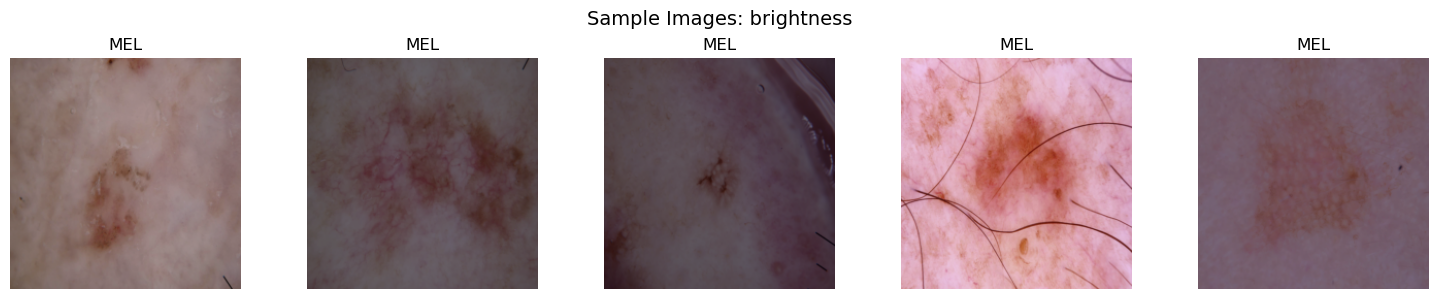

Evaluating brightness: 100%|███████████████████████████████████████████████████████████| 48/48 [03:37<00:00,  4.54s/it]


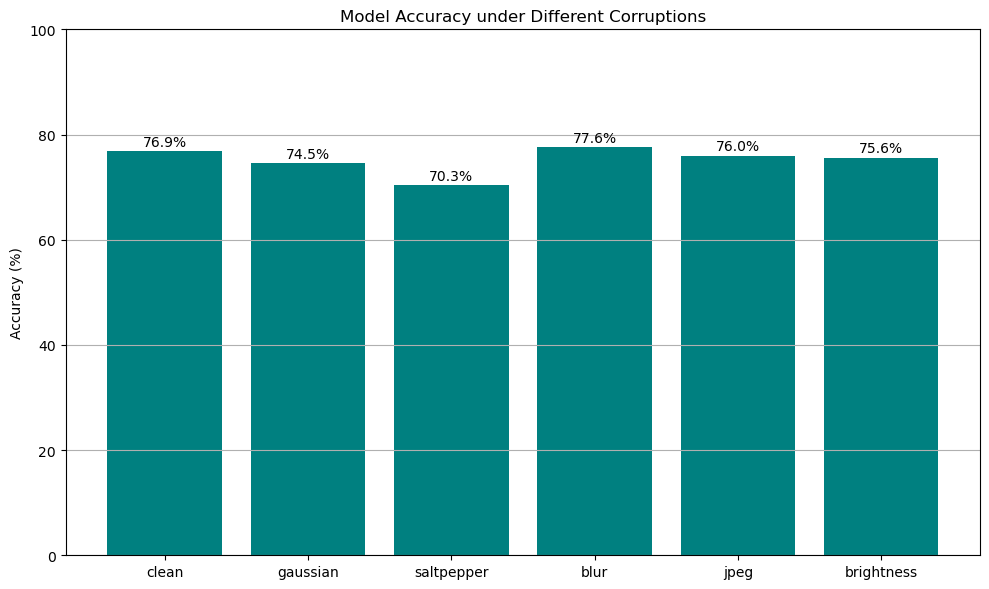


=== Accuracy Summary ===
clean       : 76.89%
gaussian    : 74.50%
saltpepper  : 70.32%
blur        : 77.62%
jpeg        : 75.96%
brightness  : 75.63%


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === Configuration ===
class Config:
    model_path = "vit_noiseaware_gaussian.pth"
    test_dir = "data/test"
    img_size = 224
    batch_size = 32
    num_classes = 7
    class_names = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC']
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# === Noise-aware attention module ===
class DeeperNoiseDetector(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Linear(dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


class NoiseAwareAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.detector = DeeperNoiseDetector(dim)

    def forward(self, x):
        noise_scores = self.detector(x)
        min_r = 0.2
        mask = min_r + (1 - noise_scores) * (1 - min_r)
        return x * mask, noise_scores


# === Model Definition ===
class NoiseAwareViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=Config.num_classes)
        self.noise_aware = NoiseAwareAttention(self.vit.embed_dim)

    def forward(self, x):
        B = x.size(0)
        x = self.vit.patch_embed(x)
        cls_token = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed[:, :x.size(1)]
        x = self.vit.pos_drop(x)
        patch_tokens, noise_scores = self.noise_aware(x[:, 1:])
        x = torch.cat([x[:, :1], patch_tokens], dim=1)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        logits = self.vit.head(x[:, 0])
        return logits, noise_scores


# === Noise Corruption Transforms ===
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

class GaussianNoise:
    def __call__(self, x): return torch.clamp(x + 0.1 * torch.randn_like(x), 0, 1)

class SaltPepper:
    def __call__(self, x):
        prob = 0.05
        rnd = torch.rand_like(x)
        salt = (rnd > (1 - prob / 2)).float()
        pepper = (rnd < prob / 2).float()
        return x * (1 - salt - pepper) + salt

class Blur:
    def __init__(self): self.blur = transforms.GaussianBlur(kernel_size=5, sigma=(1.0, 2.0))
    def __call__(self, x): return self.blur(x)

class JPEG:
    def __call__(self, x):
        img = transforms.ToPILImage()(x)
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=30)
        buf.seek(0)
        return transforms.ToTensor()(Image.open(buf))

test_transforms = {
    'clean': transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        normalize
    ]),
    'gaussian': transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        GaussianNoise(),
        normalize
    ]),
    'saltpepper': transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        SaltPepper(),
        normalize
    ]),
    'blur': transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        Blur(),
        normalize
    ]),
    'jpeg': transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        JPEG(),
        normalize
    ]),
    'brightness': transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ColorJitter(brightness=0.6),
        transforms.ToTensor(),
        normalize
    ])
}


# === Evaluation ===
def load_model(path):
    model = NoiseAwareViT().to(Config.device)
    model.load_state_dict(torch.load(path, map_location=Config.device))
    model.eval()
    return model

def evaluate(model, loader, corruption_name, show_confusion=False):
    all_preds, all_labels = [], []
    correct = 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Evaluating {corruption_name}"):
            x, y = x.to(Config.device), y.to(Config.device)
            logits, _ = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            correct += (preds == y).sum().item()

    acc = 100 * correct / len(loader.dataset)

    if show_confusion:
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=Config.class_names)
        disp.plot(xticks_rotation=45, cmap="Blues")
        plt.title(f"Confusion Matrix - {corruption_name}")
        plt.tight_layout()
        plt.show()

    return acc

def visualize_samples(loader, title, n=5):
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    plt.figure(figsize=(15, 3))
    for i in range(n):
        img = x[i].permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(Config.class_names[y[i]])
        plt.axis('off')
    plt.suptitle(f"Sample Images: {title}", fontsize=14)
    plt.tight_layout()
    plt.show()

def run_evaluation():
    model = load_model(Config.model_path)
    results = {}

    for name, transform in test_transforms.items():
        dataset = datasets.ImageFolder(Config.test_dir, transform=transform)
        loader = DataLoader(dataset, batch_size=Config.batch_size, shuffle=False)
        visualize_samples(loader, name)
        acc = evaluate(model, loader, name, show_confusion=(name == 'clean' or name == 'gaussian'))
        results[name] = acc

    # Bar Plot
    plt.figure(figsize=(10, 6))
    keys = list(results.keys())
    values = [results[k] for k in keys]
    plt.bar(keys, values, color='teal')
    plt.ylabel("Accuracy (%)")
    plt.title("Model Accuracy under Different Corruptions")
    plt.ylim(0, 100)
    plt.grid(axis='y')
    for i, v in enumerate(values):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center')
    plt.tight_layout()
    plt.show()

    # Summary
    print("\n=== Accuracy Summary ===")
    for k, v in results.items():
        print(f"{k:<12}: {v:.2f}%")

if __name__ == "__main__":
    run_evaluation()
